### Substitutions

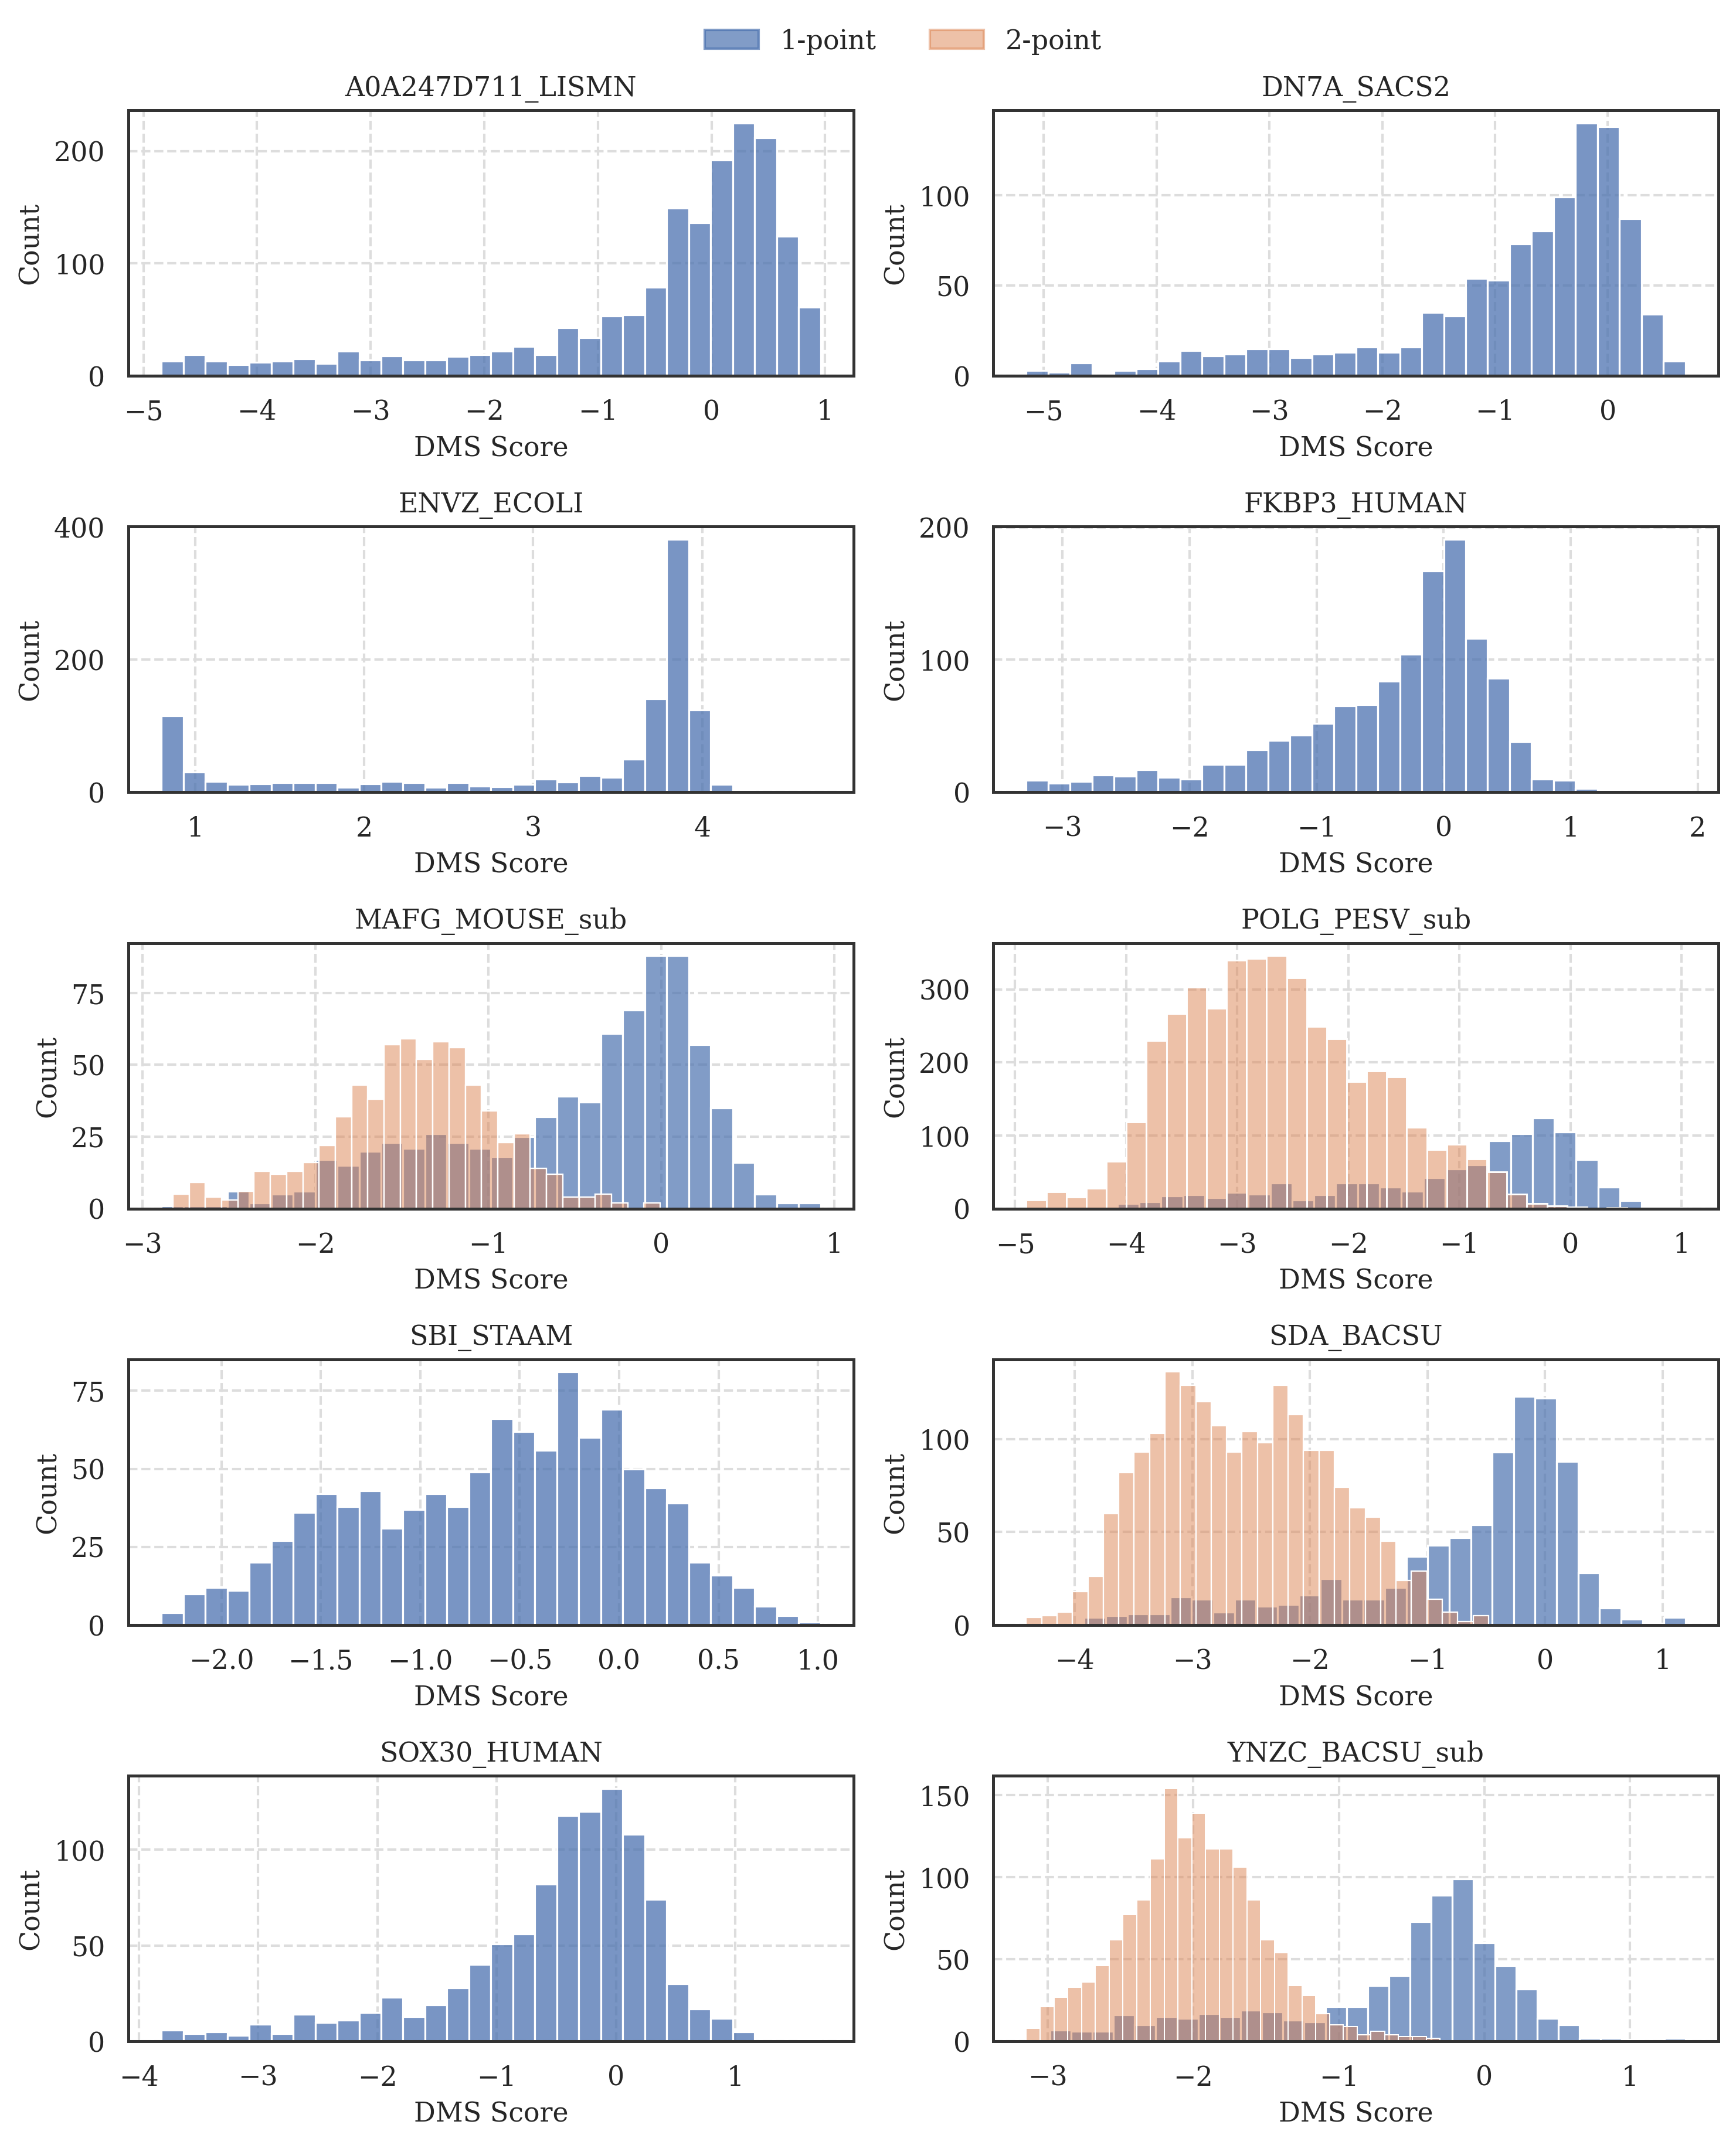

In [39]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
import matplotlib.patches as mpatches

# ------------------------
# Style (your settings)
# ------------------------
sns.set_theme(
    context="notebook",
    style="whitegrid",
    font="DejaVu Serif",
    rc={
        "figure.dpi": 300,
        "axes.linewidth": 1.2,
        "axes.edgecolor": "#333333",
        "grid.color": "#DDDDDD",
        "grid.linestyle": "--",
        "legend.frameon": False,
    }
)

mpl.rcParams.update({
    "font.family": "DejaVu Serif",
    "font.size": 11,
    "axes.titlesize": 11,
    "axes.labelsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "legend.title_fontsize": 11,
    "figure.titlesize": 11,
})

# ------------------------
# Paths
# ------------------------
processed_dir = "../../../data/proteingym_dms/processed/substitutions/"
files = sorted([f for f in os.listdir(processed_dir) if f.endswith(".csv")])

name_map = {
    "YNZC_BACSU_Tsuboyama_2023_2JVD.csv": "YNZC_BACSU_sub",
    "MAFG_MOUSE_Tsuboyama_2023_1K1V.csv": "MAFG_MOUSE_sub",
    "SDA_BACSU_Tsuboyama_2023_1PV0.csv": "SDA_BACSU",
    "POLG_PESV_Tsuboyama_2023_2MXD.csv": "POLG_PESV_sub",
    "DN7A_SACS2_Tsuboyama_2023_1JIC.csv": "DN7A_SACS2",
    "SBI_STAAM_Tsuboyama_2023_2JVG.csv": "SBI_STAAM",
    "SOX30_HUMAN_Tsuboyama_2023_7JJK.csv": "SOX30_HUMAN",
    "ENVZ_ECOLI_Ghose_2023.csv": "ENVZ_ECOLI",
    "FKBP3_HUMAN_Tsuboyama_2023_2KFV.csv": "FKBP3_HUMAN",
    "A0A247D711_LISMN_Stadelmann_2021.csv": "A0A247D711_LISMN"
}

# Colors for 1- and 2-point mutations
COLOR_ONE = "#4C72B0"
COLOR_TWO = "#DD8452"

# ------------------------
# Create 5x2 grid
# ------------------------
fig, axes = plt.subplots(5, 2, figsize=(10, 12))
axes = axes.flatten()

# ------------------------
# Loop through datasets
# ------------------------
for i, file_name in enumerate(files):
    ax = axes[i]
    file_path = os.path.join(processed_dir, file_name)

    df = pd.read_csv(file_path)

    # Recompute mutation counts
    mutation_counts = df["mutant"].astype(str).apply(lambda x: len(x.split(":")))

    one_mut = df[mutation_counts == 1]["score"]
    two_mut = df[mutation_counts == 2]["score"]

    # ------------------------
    # Plot logic
    # ------------------------
    if len(one_mut) > 0 and len(two_mut) > 0:
        sns.histplot(one_mut, bins=30, ax=ax, alpha=0.7, color=COLOR_ONE)
        sns.histplot(two_mut, bins=30, ax=ax, alpha=0.5, color=COLOR_TWO)
    elif len(one_mut) > 0:
        sns.histplot(one_mut, bins=30, ax=ax, color=COLOR_ONE)
    elif len(two_mut) > 0:
        sns.histplot(two_mut, bins=30, ax=ax, color=COLOR_TWO)
    else:
        sns.histplot(df["score"], bins=30, ax=ax, color=COLOR_ONE)

    # Title cleanup
    ax.set_title(name_map.get(file_name, file_name.replace(".csv", "")))
    ax.set_xlabel("DMS Score")
    ax.set_ylabel("Count")

# ------------------------
# Remove empty subplots (if any)
# ------------------------
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# ------------------------
# Single legend at top center
# ------------------------
handles = [
    mpatches.Patch(color=COLOR_ONE, alpha=0.7, label="1-point"),
    mpatches.Patch(color=COLOR_TWO, alpha=0.5, label="2-point")
]

fig.legend(
    handles=handles,
    loc='upper center',
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.52, 1.02)
)

plt.tight_layout()
plt.show()

### Indels

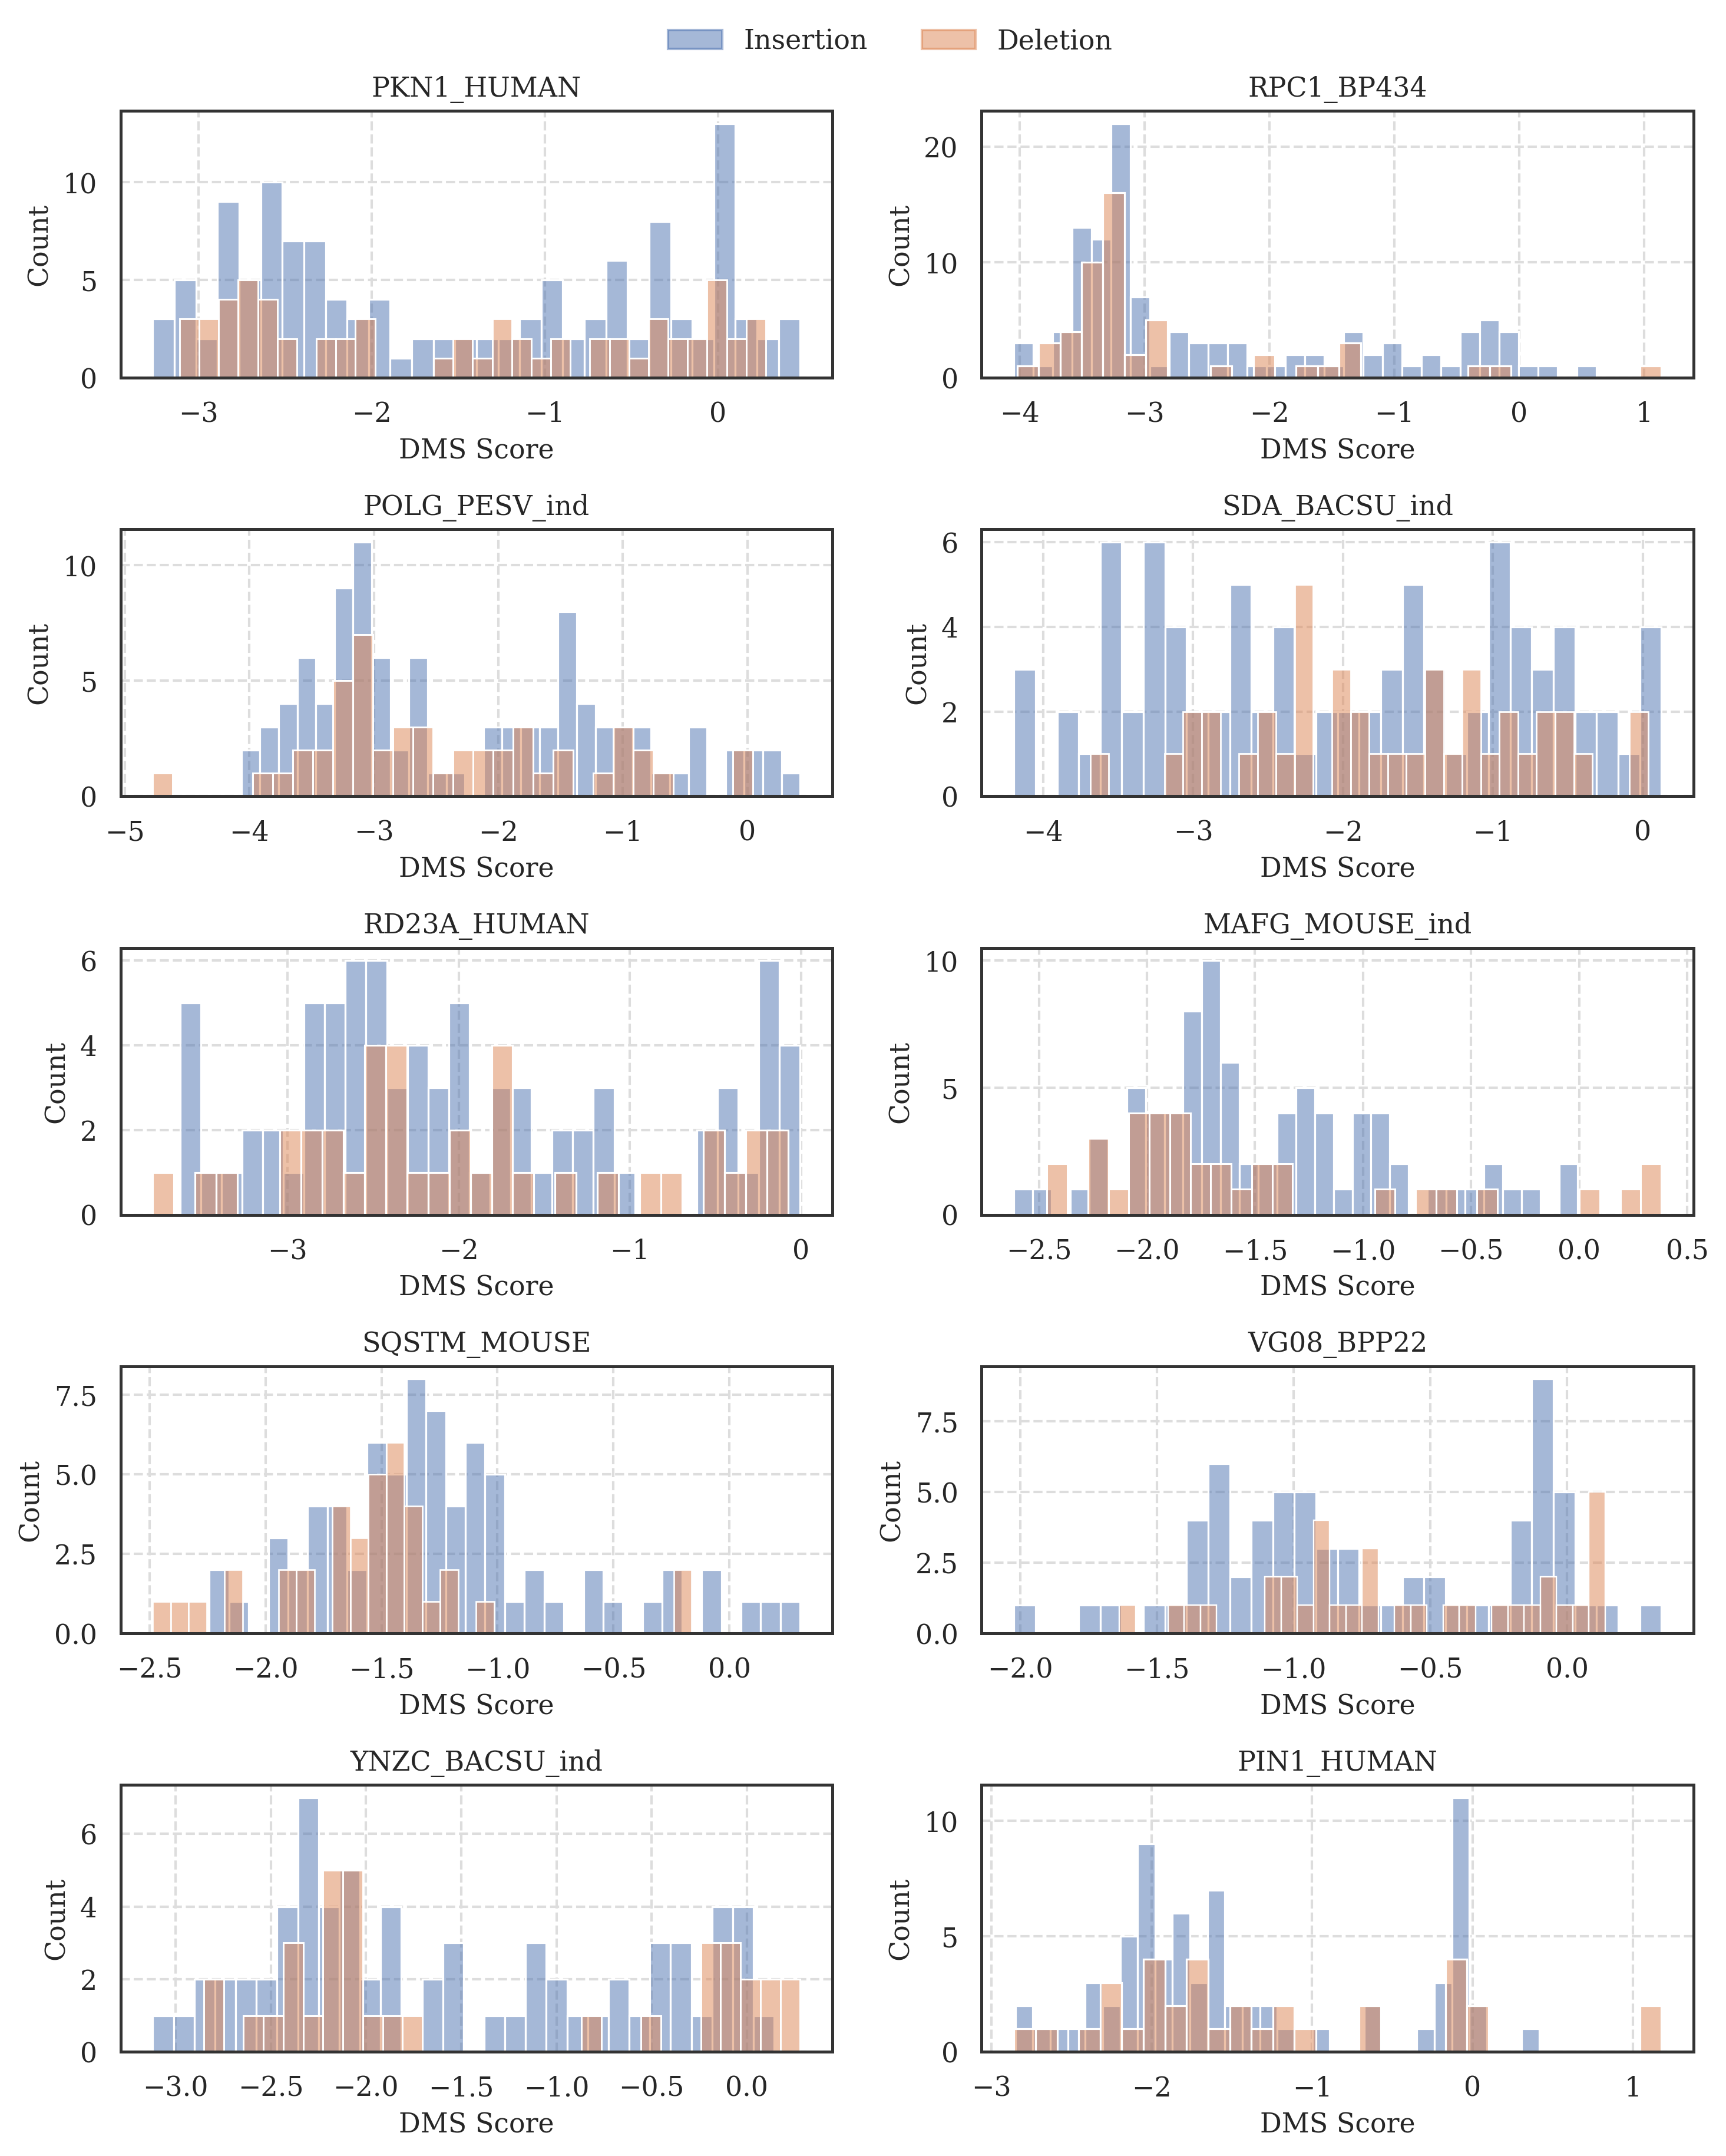

In [38]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
import matplotlib.patches as mpatches

# ------------------------
# Style (unchanged)
# ------------------------
sns.set_theme(
    context="notebook",
    style="whitegrid",
    font="DejaVu Serif",
    rc={
        "figure.dpi": 300,
        "axes.linewidth": 1.2,
        "axes.edgecolor": "#333333",
        "grid.color": "#DDDDDD",
        "grid.linestyle": "--",
        "legend.frameon": False,
    }
)

mpl.rcParams.update({
    "font.family": "DejaVu Serif",
    "font.size": 11,
    "axes.titlesize": 11,
    "axes.labelsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "legend.title_fontsize": 11,
    "figure.titlesize": 11,
})

# ------------------------
# Path (processed data)
# ------------------------
processed_dir = "../../../data/proteingym_dms/processed/indels/"

files = [
    "PKN1_HUMAN_Tsuboyama_2023_1URF_indels.csv",
    "RPC1_BP434_Tsuboyama_2023_1R69_indels.csv",
    "POLG_PESV_Tsuboyama_2023_2MXD_indels.csv",
    "SDA_BACSU_Tsuboyama_2023_1PV0_indels.csv",
    "RD23A_HUMAN_Tsuboyama_2023_1IFY_indels.csv",
    "MAFG_MOUSE_Tsuboyama_2023_1K1V_indels.csv",
    "SQSTM_MOUSE_Tsuboyama_2023_2RRU_indels.csv",
    "VG08_BPP22_Tsuboyama_2023_2GP8_indels.csv",
    "YNZC_BACSU_Tsuboyama_2023_2JVD_indels.csv",
    "PIN1_HUMAN_Tsuboyama_2023_1I6C_indels.csv",
]

# ------------------------
# Custom names
# ------------------------
name_map = {
    "PIN1_HUMAN_Tsuboyama_2023_1I6C_indels.csv": "PIN1_HUMAN",
    "YNZC_BACSU_Tsuboyama_2023_2JVD_indels.csv": "YNZC_BACSU_ind",
    "VG08_BPP22_Tsuboyama_2023_2GP8_indels.csv": "VG08_BPP22",
    "SQSTM_MOUSE_Tsuboyama_2023_2RRU_indels.csv": "SQSTM_MOUSE",
    "MAFG_MOUSE_Tsuboyama_2023_1K1V_indels.csv": "MAFG_MOUSE_ind",
    "RD23A_HUMAN_Tsuboyama_2023_1IFY_indels.csv": "RD23A_HUMAN",
    "SDA_BACSU_Tsuboyama_2023_1PV0_indels.csv": "SDA_BACSU_ind",
    "POLG_PESV_Tsuboyama_2023_2MXD_indels.csv": "POLG_PESV_ind",
    "RPC1_BP434_Tsuboyama_2023_1R69_indels.csv": "RPC1_BP434",
    "PKN1_HUMAN_Tsuboyama_2023_1URF_indels.csv": "PKN1_HUMAN",
}

# ------------------------
# Colors (match substitutions)
# ------------------------
COLOR_INSERT = "#4C72B0"   # Blue
COLOR_DELETE = "#DD8452"   # Orange

# ------------------------
# Create 5x2 grid
# ------------------------
fig, axes = plt.subplots(5, 2, figsize=(10, 12))
axes = axes.flatten()

# ------------------------
# Loop through files
# ------------------------
for i, file_name in enumerate(files):
    ax = axes[i]
    file_path = os.path.join(processed_dir, file_name)
    df = pd.read_csv(file_path)

    # ------------------------
    # Infer WT length
    # ------------------------
    seq_lengths = df["sequence"].str.len()
    wt_len = (seq_lengths.min() + seq_lengths.max()) / 2
    length_diff = df["sequence"].str.len() - wt_len

    insertions = df[length_diff > 0]["score"]
    deletions  = df[length_diff < 0]["score"]

    # ------------------------
    # Plot histograms
    # ------------------------
    if len(insertions) > 0:
        sns.histplot(
            insertions,
            bins=30,
            ax=ax,
            alpha=0.5,
            color=COLOR_INSERT
        )

    if len(deletions) > 0:
        sns.histplot(
            deletions,
            bins=30,
            ax=ax,
            alpha=0.5,
            color=COLOR_DELETE
        )

    # ------------------------
    # Labels
    # ------------------------
    ax.set_title(name_map[file_name])
    ax.set_xlabel("DMS Score")
    ax.set_ylabel("Count")

# ------------------------
# Remove empty axes
# ------------------------
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# ------------------------
# Single legend at top center
# ------------------------
handles = [
    mpatches.Patch(color=COLOR_INSERT, alpha=0.5, label="Insertion"),
    mpatches.Patch(color=COLOR_DELETE, alpha=0.5, label="Deletion")
]

fig.legend(
    handles=handles,
    loc='upper center',
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.52, 1.02)
)

plt.tight_layout()
plt.show()

### Short AMPs, CellPPD, and ToxinPred3

/var/folders/hl/051_xdcn7bnfs79b2g9vrw7c0000gn/T/ipykernel_1067/3772191662.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cell_counts.index, y=cell_counts.values, ax=ax_cell, palette=CLASS_COLORS)
/var/folders/hl/051_xdcn7bnfs79b2g9vrw7c0000gn/T/ipykernel_1067/3772191662.py:83: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=toxin_counts.index, y=toxin_counts.values, ax=ax_toxin, palette=CLASS_COLORS)


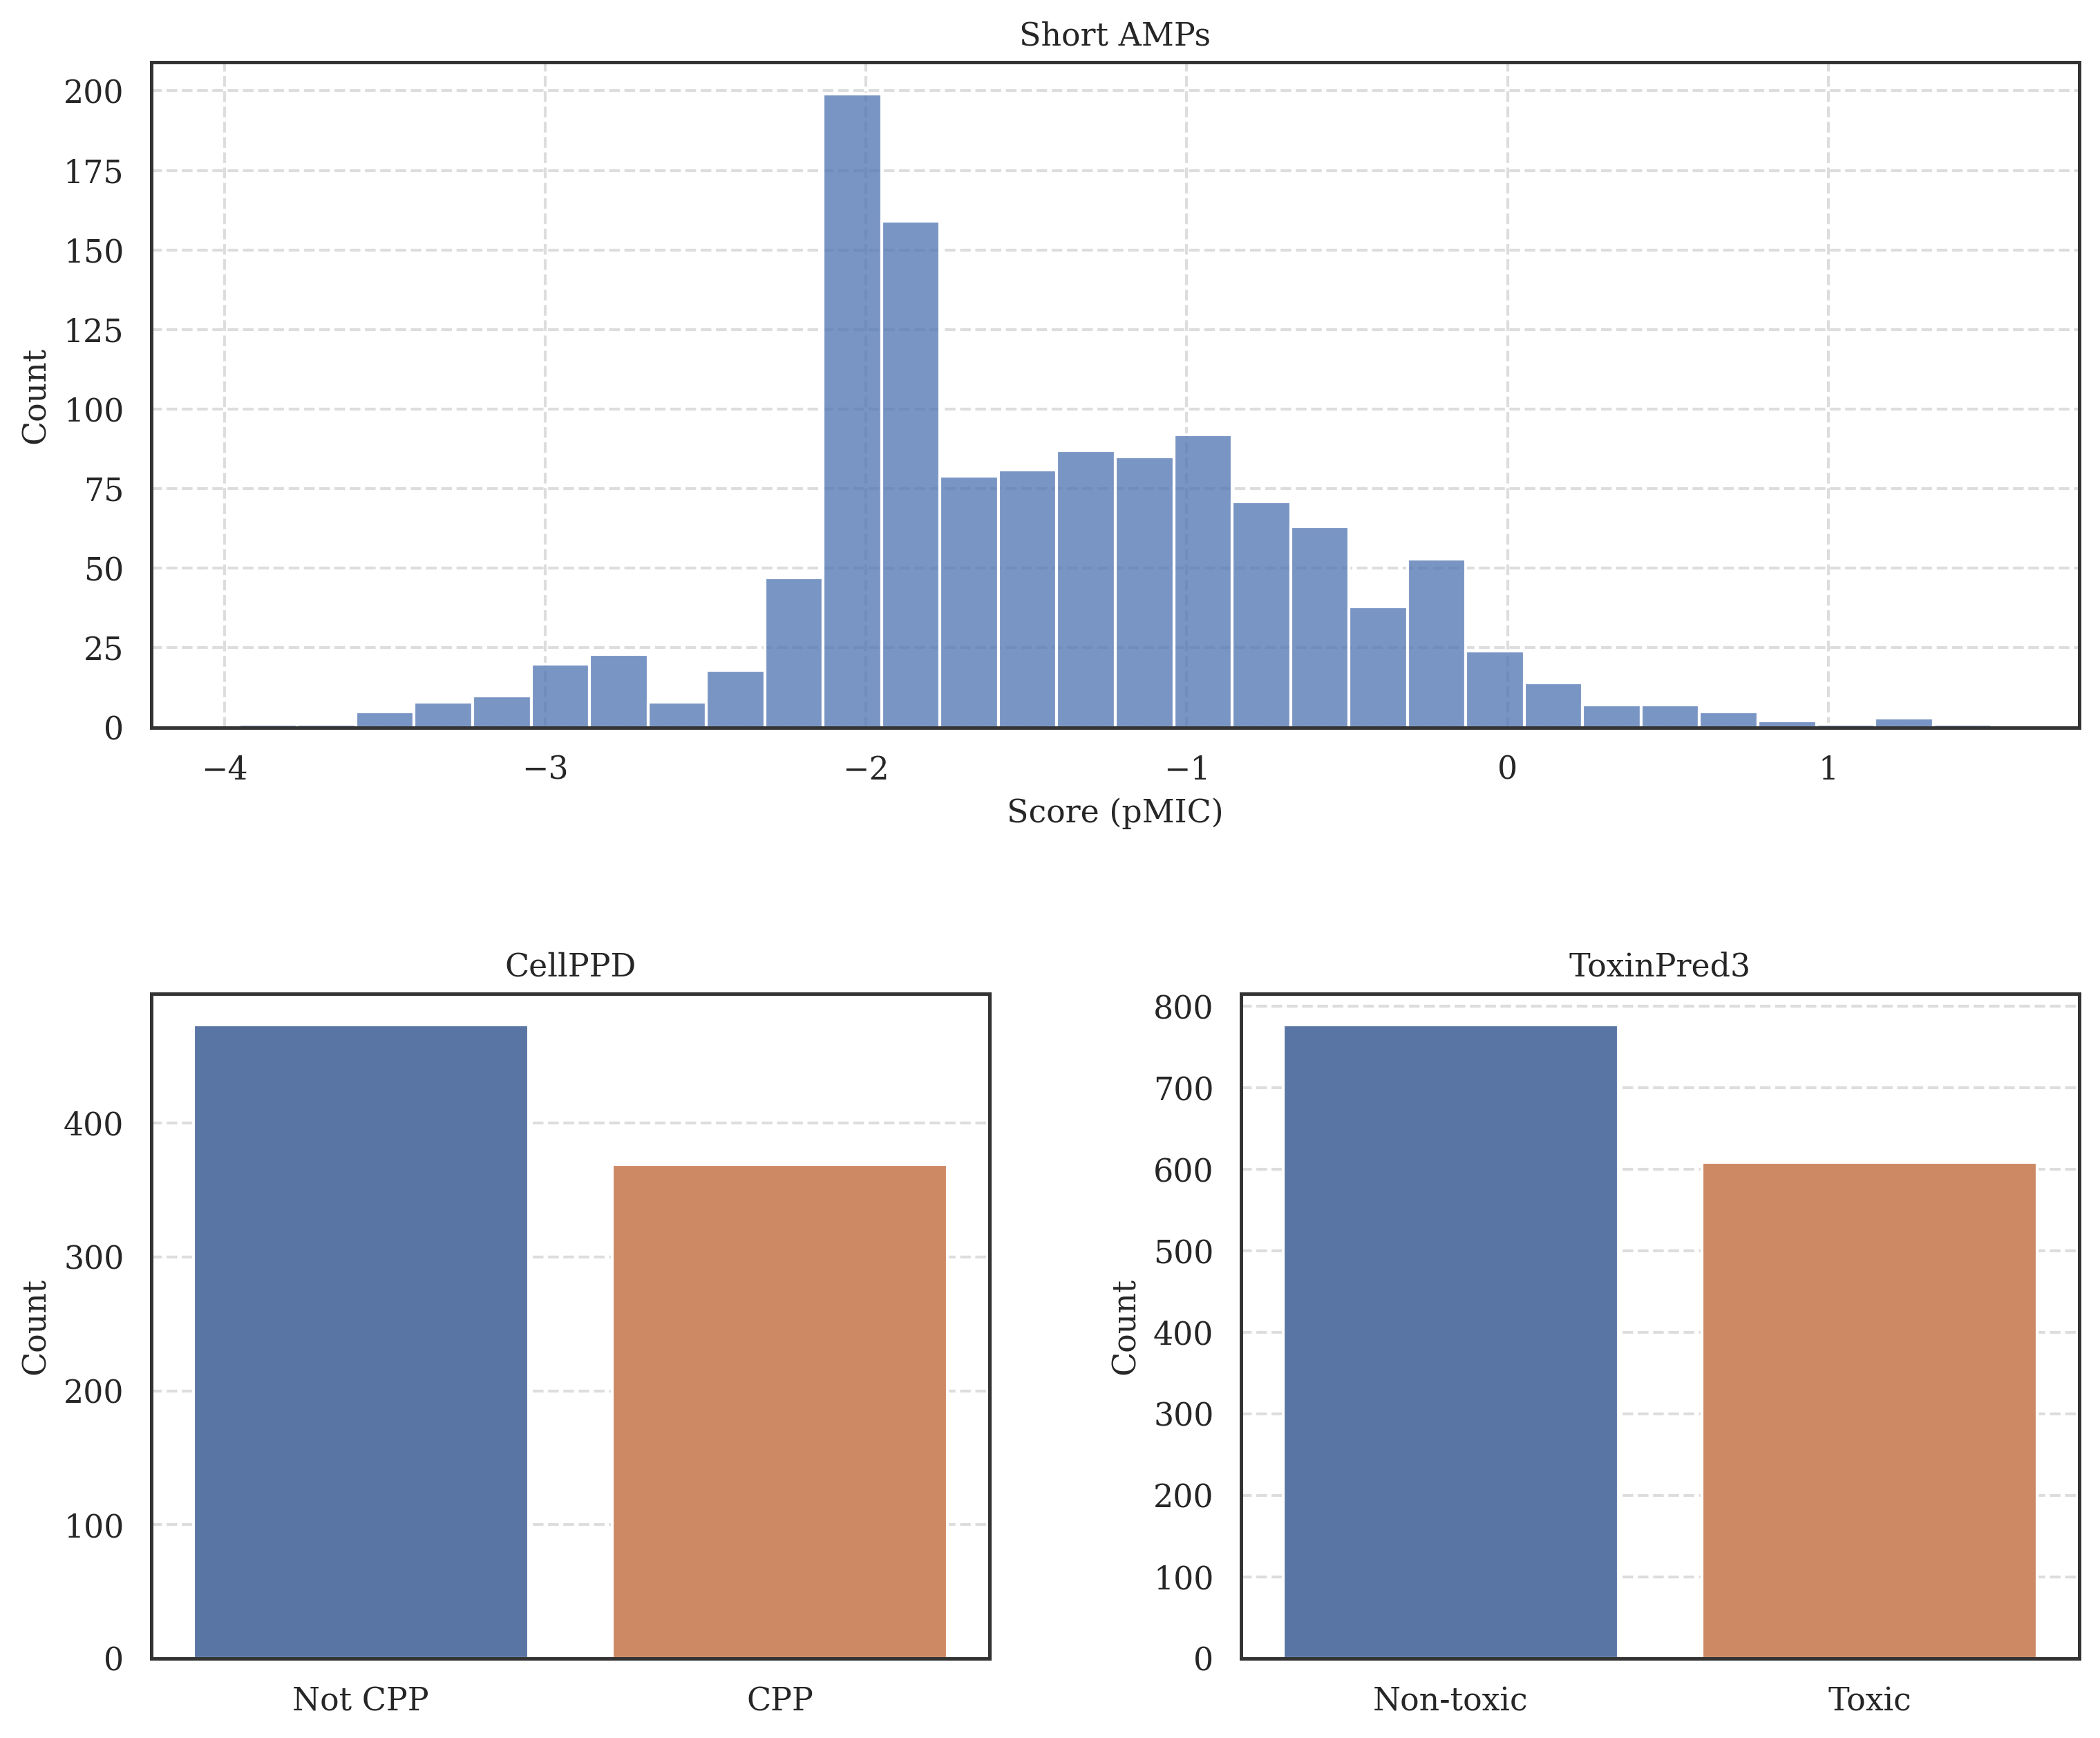

In [33]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

# ------------------------
# Style (same as before)
# ------------------------
sns.set_theme(
    context="notebook",
    style="whitegrid",
    font="DejaVu Serif",
    rc={
        "figure.dpi": 300,
        "axes.linewidth": 1.2,
        "axes.edgecolor": "#333333",
        "grid.color": "#DDDDDD",
        "grid.linestyle": "--",
        "legend.frameon": False,
    }
)

mpl.rcParams.update({
    "font.family": "DejaVu Serif",
    "font.size": 11,
    "axes.titlesize": 11,
    "axes.labelsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
})

# ------------------------
# Paths
# ------------------------
base_dir = "../../../data/"

ec_path = os.path.join(base_dir, "mbc/processed/EC.csv")
cellppd_path = os.path.join(base_dir, "cellppd/processed/cellppd.csv")
toxin_path = os.path.join(base_dir, "toxinpred3/processed/toxinpred3.csv")

# ------------------------
# Load data
# ------------------------
df_ec = pd.read_csv(ec_path)
df_cell = pd.read_csv(cellppd_path)
df_toxin = pd.read_csv(toxin_path)

# ------------------------
# Colors
# ------------------------
MAIN_COLOR = "#4C72B0"     # blue for regression
CLASS_COLORS = ["#4C72B0", "#DD8452"]  # blue/orange for classes

# ------------------------
# Create hybrid figure
# ------------------------
fig = plt.figure(figsize=(12, 10))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1], width_ratios=[1,1], hspace=0.4, wspace=0.3)

# ------------------------
# Top row: EC histogram (span both columns)
# ------------------------
ax_ec = fig.add_subplot(gs[0, :])
sns.histplot(df_ec["score"], bins=30, ax=ax_ec, color=MAIN_COLOR)
ax_ec.set_title("Short AMPs")
ax_ec.set_xlabel("Score (pMIC)")
ax_ec.set_ylabel("Count")

# ------------------------
# Bottom row: CellPPD & ToxinPred3 bar plots
# ------------------------
ax_cell = fig.add_subplot(gs[1, 0])
cell_counts = df_cell["classes"].value_counts()
sns.barplot(x=cell_counts.index, y=cell_counts.values, ax=ax_cell, palette=CLASS_COLORS)
ax_cell.set_title("CellPPD")
ax_cell.set_xlabel("")
ax_cell.set_ylabel("Count")

ax_toxin = fig.add_subplot(gs[1, 1])
toxin_counts = df_toxin["classes"].value_counts()
sns.barplot(x=toxin_counts.index, y=toxin_counts.values, ax=ax_toxin, palette=CLASS_COLORS)
ax_toxin.set_title("ToxinPred3")
ax_toxin.set_xlabel("")
ax_toxin.set_ylabel("Count")

plt.show()

### Range of each dataset

In [35]:
import os
import pandas as pd

# ------------------------
# Define all processed dataset paths
# ------------------------

base_dirs = {
    "substitutions": "../../../data/proteingym_dms/processed/substitutions/",
    "indels": "../../../data/proteingym_dms/processed/indels/",
    "EC": "../../../data/mbc/processed/",
    "CellPPD": "../../../data/cellppd/processed/",
    "ToxinPred3": "../../../data/toxinpred3/processed/"
}

# List of files for each category
sub_files = [
    "YNZC_BACSU_Tsuboyama_2023_2JVD.csv",
    "MAFG_MOUSE_Tsuboyama_2023_1K1V.csv",
    "SDA_BACSU_Tsuboyama_2023_1PV0.csv",
    "POLG_PESV_Tsuboyama_2023_2MXD.csv",
    "DN7A_SACS2_Tsuboyama_2023_1JIC.csv",
    "SBI_STAAM_Tsuboyama_2023_2JVG.csv",
    "SOX30_HUMAN_Tsuboyama_2023_7JJK.csv",
    "ENVZ_ECOLI_Ghose_2023.csv",
    "FKBP3_HUMAN_Tsuboyama_2023_2KFV.csv",
    "A0A247D711_LISMN_Stadelmann_2021.csv"
]

indel_files = [
    "PKN1_HUMAN_Tsuboyama_2023_1URF_indels.csv",
    "RPC1_BP434_Tsuboyama_2023_1R69_indels.csv",
    "POLG_PESV_Tsuboyama_2023_2MXD_indels.csv",
    "SDA_BACSU_Tsuboyama_2023_1PV0_indels.csv",
    "RD23A_HUMAN_Tsuboyama_2023_1IFY_indels.csv",
    "MAFG_MOUSE_Tsuboyama_2023_1K1V_indels.csv",
    "SQSTM_MOUSE_Tsuboyama_2023_2RRU_indels.csv",
    "VG08_BPP22_Tsuboyama_2023_2GP8_indels.csv",
    "YNZC_BACSU_Tsuboyama_2023_2JVD_indels.csv",
    "PIN1_HUMAN_Tsuboyama_2023_1I6C_indels.csv"
]

# AMP/CPP/toxin datasets
other_files = {
    "EC": "EC.csv"
}

# ------------------------
# Storage for results
# ------------------------
summary_rows = []

# ------------------------
# Helper function to compute min/max
# ------------------------
def get_min_max(file_path, score_col="score"):
    df = pd.read_csv(file_path)
    if score_col not in df.columns:
        # fallback: use first numeric column
        num_cols = df.select_dtypes(include="number").columns
        if len(num_cols) == 0:
            return None, None
        score_col = num_cols[0]
    return df[score_col].min(), df[score_col].max()

# ------------------------
# Process substitutions
# ------------------------
for f in sub_files:
    path = os.path.join(base_dirs["substitutions"], f)
    min_val, max_val = get_min_max(path, score_col="score")
    summary_rows.append({
        "dataset": f.replace(".csv", ""),
        "type": "substitution",
        "min": min_val,
        "max": max_val
    })

# ------------------------
# Process indels
# ------------------------
for f in indel_files:
    path = os.path.join(base_dirs["indels"], f)
    min_val, max_val = get_min_max(path, score_col="score")
    summary_rows.append({
        "dataset": f.replace(".csv", ""),
        "type": "indel",
        "min": min_val,
        "max": max_val
    })

# ------------------------
# Process other datasets
# ------------------------
for key, f in other_files.items():
    path = os.path.join(base_dirs[key], f)
    # Column may differ
    score_col = "score" if key != "EC" else "score"  # EC already processed as score
    min_val, max_val = get_min_max(path, score_col=score_col)
    summary_rows.append({
        "dataset": key,
        "type": "other",
        "min": min_val,
        "max": max_val
    })

# ------------------------
# Combine into DataFrame
# ------------------------
summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.sort_values(by=["type", "dataset"]).reset_index(drop=True)

print(summary_df)

                                   dataset          type       min       max
0    MAFG_MOUSE_Tsuboyama_2023_1K1V_indels         indel -2.615109  0.380024
1    PIN1_HUMAN_Tsuboyama_2023_1I6C_indels         indel -2.858837  1.176339
2    PKN1_HUMAN_Tsuboyama_2023_1URF_indels         indel -3.263446  0.475923
3     POLG_PESV_Tsuboyama_2023_2MXD_indels         indel -4.773988  0.423693
4   RD23A_HUMAN_Tsuboyama_2023_1IFY_indels         indel -3.786609 -0.004490
5    RPC1_BP434_Tsuboyama_2023_1R69_indels         indel -4.043648  1.138779
6     SDA_BACSU_Tsuboyama_2023_1PV0_indels         indel -4.195453  0.123338
7   SQSTM_MOUSE_Tsuboyama_2023_2RRU_indels         indel -2.485281  0.304827
8    VG08_BPP22_Tsuboyama_2023_2GP8_indels         indel -2.022041  0.345147
9    YNZC_BACSU_Tsuboyama_2023_2JVD_indels         indel -3.119119  0.280233
10                                      EC         other -3.954243  1.508638
11        A0A247D711_LISMN_Stadelmann_2021  substitution -4.841852  0.959943